## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load dataset

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Shape and column overview
print(df.shape)
print(df.dtypes)
df.head()

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
#check for missing values

df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
#check for duplicates

df.duplicated().sum()

0

In [9]:
# Check churn rate 
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


**We have over 70% of customer churn rate.**

## Data cleaning

In [11]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
# Check for nulls 
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


**I dropped rows where TotalCharges was null because these 11 customers never completed a billing cycle and don't represent churn risk."**

In [13]:
# Drop the 11 rows with null values (no assumption allowed)
df = df.dropna(subset=['TotalCharges']) 

In [14]:
# Convert Churn to binary integer
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

df.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_12420\405677834.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


### Drop not so useful column

In [15]:
# Drop customerID (not useful for analysis)
df = df.drop(columns=['customerID'])

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


### Renaming some columns

In [19]:
# Renaming gender, and tenure

df = df.rename(columns = {'gender' : 'Gender', 'tenure' : 'Tenure'})

df.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [40]:
# Calculate the percentage of churned customers with tenure <= 12 months
churned_customers = df[df['Churn_Binary'] == 1]
churned_within_12 = churned_customers[churned_customers['Tenure'] <= 12]
percentage = (len(churned_within_12) / len(churned_customers)) * 100

print(f"Total churned customers: {len(churned_customers)}")
print(f"Churned within first 12 months: {len(churned_within_12)}")
print(f"Percentage: {percentage:.1f}%")

Total churned customers: 1869
Churned within first 12 months: 1037
Percentage: 55.5%


## Visualizations

### Tenure distribution by churn (stacked histogram) 

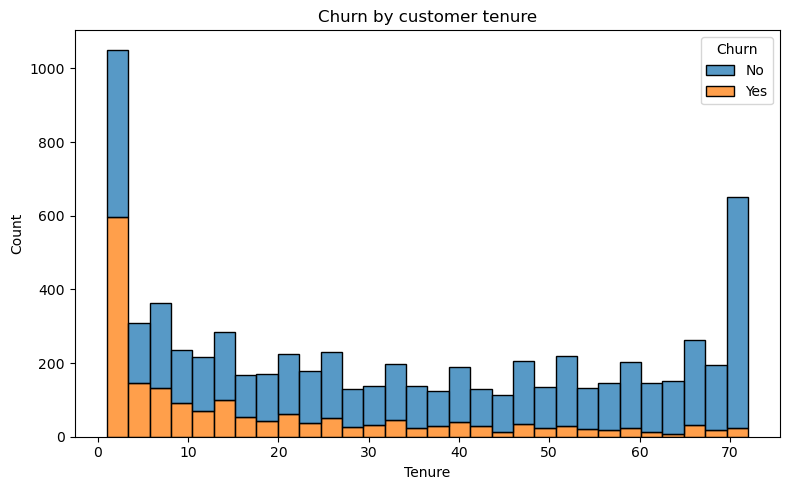

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Tenure', hue='Churn',
             multiple='stack', bins=30)
plt.title('Churn by customer tenure')
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150)
plt.show()

### Churn rate by contract type (bar chart)

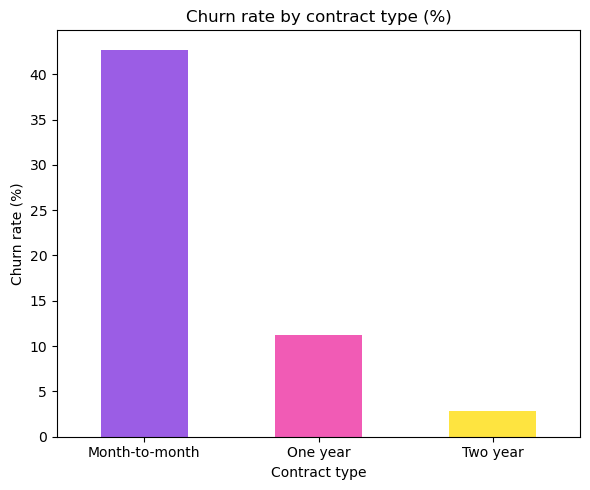

In [37]:
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
plt.figure(figsize=(6, 5))
colors_contract = ['#9B5DE5', '#F15BB5', '#FEE440']  # purple, pink, yellow
contract_churn.plot(kind='bar', color=colors_contract)
plt.title('Churn rate by contract type (%)')
plt.ylabel('Churn rate (%)')
plt.xlabel('Contract type')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()

### Monthly charges boxplot (churned vs retained)

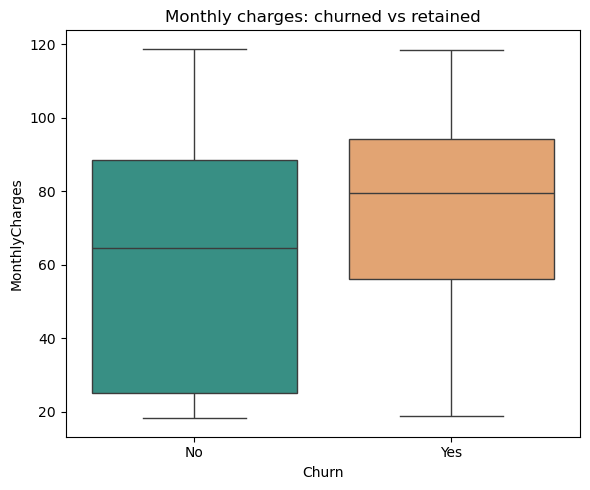

In [31]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            hue='Churn', palette={'Yes': '#F4A261', 'No': '#2A9D8F'},
            legend=False)   # desert orange + teal
plt.title('Monthly charges: churned vs retained')
plt.tight_layout()
plt.savefig('monthly_charges_boxplot.png', dpi=150)
plt.show()

### Churn rate by internet service type (bar chart)

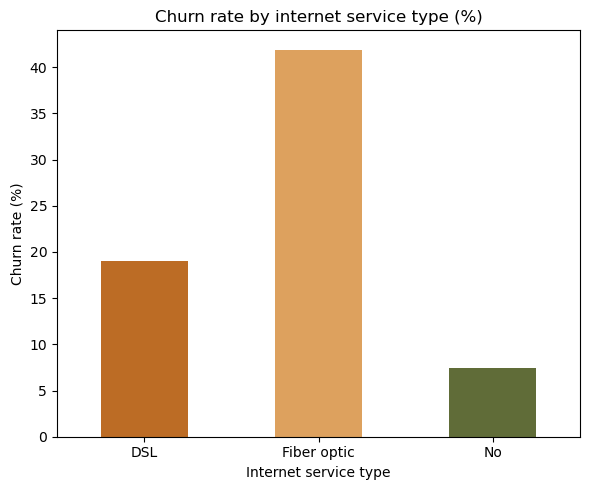

In [36]:
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean() * 100
plt.figure(figsize=(6, 5))
colors_internet = ['#BC6C25', '#DDA15E', '#606C38']   # brown, sand, olive
internet_churn.plot(kind='bar', color=colors_internet)
plt.title('Churn rate by internet service type (%)')
plt.ylabel('Churn rate (%)')
plt.xlabel('Internet service type')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.savefig('churn_by_internet_service.png', dpi=150)
plt.show()

##  Cohort analysis

In [38]:
# Create a risk segmentation table
risk_table = df.groupby(['Contract', 'InternetService']).agg(
    total_customers=('Churn_Binary', 'count'),
    churned=('Churn_Binary', 'sum'),
    churn_rate=('Churn_Binary', 'mean'),
    avg_monthly_charge=('MonthlyCharges', 'mean')
).reset_index()

risk_table['churn_rate'] = (risk_table['churn_rate'] * 100).round(1)
risk_table.sort_values('churn_rate', ascending=False)

,Contract,InternetService,total_customers,churned,churn_rate,avg_monthly_charge
1,Month-to-month,Fiber optic,2128,1162,54.6,87.021194
0,Month-to-month,DSL,1223,394,32.2,50.219501
4,One year,Fiber optic,539,104,19.3,98.779499
2,Month-to-month,No,524,99,18.9,20.409542
3,One year,DSL,570,53,9.3,61.396754
7,Two year,Fiber optic,429,31,7.2,104.571445
5,One year,No,363,9,2.5,20.822590
6,Two year,DSL,623,12,1.9,70.507303
8,Two year,No,633,5,0.8,21.773697


**Month‑to‑month Fiber optic customers churn at 54.6%, the highest churn rate among all segments. However, their average monthly charge (87.02) is significantly lower than that of longer‑term Fiber optic customers (one‑year: 98.78; two‑year: 104.57).  
Therefore, investigate service quality or price sensitivity for this segment.**

## Summarize findings

## **Telco customer churn analysis**

### Headline
- Overall churn rate: 26.5% (1,869 of 7,032 customers)

### Finding 1: Contract type is the strongest predictor
Month-to-month: 42.7% churn  
One-year:        11.3% churn  
Two-year:         2.8% churn  
**Recommendation:** Offer month-to-month customers a discount to switch to annual contracts.

### Finding 2: Early tenure is the danger zone
**55.5%** of churned customers left within the first 12 months.  
**Recommendation:** Launch an onboarding retention program for customers in months 1–6.

### Finding 3: Fiber optic + month-to-month = highest risk
**54.6%** churn rate, paying **87.02**/month on average.  
**Recommendation:** Target this segment with proactive outreach before month 3.

### Business impact estimate
If churn is reduced by 5 percentage points in the top risk segment (month-to-month and fiber optic), the company retains approximately **111,000** in annual revenue (based on avg. monthly charge (87.02) × 12).